<a href="https://colab.research.google.com/github/phamnguyengialinh/phamnguyengialinh.github.io/blob/gh-page/EDA%20BIG%20DATA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Upload file dữ liệu và tiền xử lý dữ liệu


In [17]:
# ======================================================
# 📈 EDA - PHÂN TÍCH DỮ LIỆU GIÁ CỔ PHIẾU HVN
# NGUỒN: SIMPLIZE - VIETNAM AIRLINES
# ======================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()

df = pd.read_excel("Simplize_HVN_PriceHistory_20251129.xlsx", skiprows=5)
print("Columns:", df.columns.tolist())
df.head()




Saving Simplize_HVN_PriceHistory_20251129.xlsx to Simplize_HVN_PriceHistory_20251129 (1).xlsx
Columns: ['NGÀY', 'GIÁ MỞ CỬA', 'GIÁ CAO NHẤT', 'GIÁ THẤP NHẤT', 'GIÁ ĐÓNG CỬA', 'THAY ĐỔI GIÁ', '% THAY ĐỔI', 'KHỐI LƯỢNG']


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,NGÀY,GIÁ MỞ CỬA,GIÁ CAO NHẤT,GIÁ THẤP NHẤT,GIÁ ĐÓNG CỬA,THAY ĐỔI GIÁ,% THAY ĐỔI,KHỐI LƯỢNG
0,28/11/2025,29400.0,29400.0,28900.0,28900.0,-350.0,-0.011966,549700.0
1,27/11/2025,29350.0,29600.0,29250.0,29250.0,0.0,0.000000,587700.0
2,26/11/2025,29000.0,29600.0,29000.0,29250.0,250.0,0.008621,360300.0
3,25/11/2025,29650.0,29900.0,29000.0,29000.0,-700.0,-0.023569,952100.0
4,24/11/2025,29550.0,30000.0,29550.0,29700.0,150.0,0.005076,541200.0


In [18]:
# Đổi tên cột cho dễ dùng
# Kiểm tra cột hiện tại để map chính xác
print("Before:", df.columns.tolist())

# Mapping (chỉnh nếu tên thực tế khác)
mapping = {
    "NGÀY": "Date",
    "GIÁ MỞ CỬA": "Open",
    "GIÁ CAO NHẤT": "High",
    "GIÁ THẤP NHẤT": "Low",
    "GIÁ ĐÓNG CỬA": "Close",
    "THAY ĐỔI GIÁ": "Price_Change",
    "% THAY ĐỔI": "Pct_Change",
    "KHỐI LƯỢNG": "Volume"
}

# Lấy cột hiện có (case-sensitive), cố gắng map chỉ những tên tồn tại
cols = df.columns.tolist()
new_cols = [mapping.get(c, c) for c in cols]
df.columns = new_cols

print("After:", df.columns.tolist())
df.head()

Before: ['NGÀY', 'GIÁ MỞ CỬA', 'GIÁ CAO NHẤT', 'GIÁ THẤP NHẤT', 'GIÁ ĐÓNG CỬA', 'THAY ĐỔI GIÁ', '% THAY ĐỔI', 'KHỐI LƯỢNG']
After: ['Date', 'Open', 'High', 'Low', 'Close', 'Price_Change', 'Pct_Change', 'Volume']


,Date,Open,High,Low,Close,Price_Change,Pct_Change,Volume
0,28/11/2025,29400.0,29400.0,28900.0,28900.0,-350.0,-0.011966,549700.0
1,27/11/2025,29350.0,29600.0,29250.0,29250.0,0.0,0.000000,587700.0
2,26/11/2025,29000.0,29600.0,29000.0,29250.0,250.0,0.008621,360300.0
3,25/11/2025,29650.0,29900.0,29000.0,29000.0,-700.0,-0.023569,952100.0
4,24/11/2025,29550.0,30000.0,29550.0,29700.0,150.0,0.005076,541200.0


In [19]:
# Convert types
# 1) Date
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

# 2) Các cột số: loại bỏ khoảng trắng, dấu chấm nghìn nếu có, rồi convert
num_cols = ['Open','High','Low','Close','Price_Change','Pct_Change','Volume']
for c in num_cols:
    if c in df.columns:
        # convert to string then remove common thousands sep and replace commas
        df[c] = df[c].astype(str).str.replace(r'\.','', regex=True) \
                                 .str.replace(',','.', regex=False) \
                                 .str.strip()
        df[c] = pd.to_numeric(df[c], errors='coerce')

# Kiểm tra
print(df[['Date'] + [c for c in num_cols if c in df.columns]].dtypes)
df.head()


Date            datetime64[ns]
Open                   float64
High                   float64
Low                    float64
Close                  float64
Price_Change           float64
Pct_Change             float64
Volume                 float64
dtype: object


,Date,Open,High,Low,Close,Price_Change,Pct_Change,Volume
0,2025-11-28,294000.0,294000.0,289000.0,289000.0,-3500.0,-1.196581e+16,5497000.0
1,2025-11-27,293500.0,296000.0,292500.0,292500.0,0.0,0.000000e+00,5877000.0
2,2025-11-26,290000.0,296000.0,290000.0,292500.0,2500.0,8.620690e+15,3603000.0
3,2025-11-25,296500.0,299000.0,290000.0,290000.0,-7000.0,-2.356902e+16,9521000.0
4,2025-11-24,295500.0,300000.0,295500.0,297000.0,1500.0,5.076142e+13,5412000.0


In [20]:
# Sắp xếp theo Date tăng dần (quan trọng cho chuỗi thời gian)
df = df.sort_values('Date').reset_index(drop=True)
df.head()

,Date,Open,High,Low,Close,Price_Change,Pct_Change,Volume
0,2021-11-26,1.883513e+16,1.922917e+16,1.879573e+15,1.879573e+15,NaN,NaN,39954000.0
1,2021-11-29,1.812586e+15,1.844109e+16,1.788943e+15,1.824407e+16,NaN,NaN,43763000.0
2,2021-11-30,1.820467e+16,1.851990e+15,1.812586e+15,1.812586e+15,NaN,NaN,38131000.0
3,2021-12-01,1.812586e+15,1.836228e+16,1.796824e+16,1.816526e+15,NaN,NaN,24902000.0
4,2021-12-02,1.816526e+15,1.820467e+16,1.804705e+16,1.804705e+16,NaN,NaN,22120000.0


In [21]:
# Tạo thêm biến
df['Return_pct'] = df['Close'].pct_change() * 100            # lợi suất %
df['Intraday_Range_pct'] = (df['High'] - df['Low']) / df['Low'] * 100
df['Trading_Value'] = df['Close'] * df['Volume']             # xấp xỉ (VND * shares)

# xem vài dòng
df[['Date','Open','High','Low','Close','Volume','Return_pct','Intraday_Range_pct','Trading_Value']].head()


/tmp/ipython-input-3515592400.py:2: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Return_pct'] = df['Close'].pct_change() * 100            # lợi suất %


,Date,Open,High,Low,Close,Volume,Return_pct,Intraday_Range_pct,Trading_Value
0,2021-11-26,1.883513e+16,1.922917e+16,1.879573e+15,1.879573e+15,39954000.0,NaN,923.060797,7.509645e+22
1,2021-11-29,1.812586e+15,1.844109e+16,1.788943e+15,1.824407e+16,43763000.0,870.649895,930.837004,7.984152e+23
2,2021-11-30,1.820467e+16,1.851990e+15,1.812586e+15,1.812586e+15,38131000.0,-90.064795,2.173913,6.911571e+22
3,2021-12-01,1.812586e+15,1.836228e+16,1.796824e+16,1.816526e+15,24902000.0,0.217391,2.192982,4.523514e+22
4,2021-12-02,1.816526e+15,1.820467e+16,1.804705e+16,1.804705e+16,22120000.0,893.492408,0.873362,3.992007e+23


In [22]:
# Kiểm tra nhanh
h = df.describe().T
print(h[['count','mean','std','min','25%','50%','75%','max']])

# số lượng missing
print("\nMissing per column:\n", df.isna().sum())


                     count                        mean  \
Date                  1000  2023-11-30 04:42:14.400000   
Open                1000.0         10476797760796090.0   
High                1000.0         10461019434044356.0   
Low                 1000.0         10393848630119192.0   
Close               1000.0         10630927761671536.0   
Price_Change         726.0                  318.870523   
Pct_Change           726.0        282050668526413.6875   
Volume              1000.0                 26347343.64   
Return_pct          1006.0                 1440.571308   
Intraday_Range_pct  1000.0                  610.982174   
Trading_Value       1000.0  313661182030566813335552.0   

                                           std                  min  \
Date                                       NaN  2021-11-26 00:00:00   
Open                        8138894015322890.0             290000.0   
High                        8652623156500676.0             294000.0   
Low                

In [23]:
# Xem các dòng có bất kỳ missing nào
rows_with_nan = df[df.isna().any(axis=1)]
rows_with_nan.head(10)

,Date,Open,High,Low,Close,Price_Change,Pct_Change,Volume,Return_pct,Intraday_Range_pct,Trading_Value
0,2021-11-26,1.883513e+16,1.922917e+16,1.879573e+15,1.879573e+15,NaN,NaN,39954000.0,NaN,923.060797,7.509645e+22
1,2021-11-29,1.812586e+15,1.844109e+16,1.788943e+15,1.824407e+16,NaN,NaN,43763000.0,870.649895,930.837004,7.984152e+23
2,2021-11-30,1.820467e+16,1.851990e+15,1.812586e+15,1.812586e+15,NaN,NaN,38131000.0,-90.064795,2.173913,6.911571e+22
3,2021-12-01,1.812586e+15,1.836228e+16,1.796824e+16,1.816526e+15,NaN,NaN,24902000.0,0.217391,2.192982,4.523514e+22
4,2021-12-02,1.816526e+15,1.820467e+16,1.804705e+16,1.804705e+16,NaN,NaN,22120000.0,893.492408,0.873362,3.992007e+23
5,2021-12-03,1.808645e+15,1.816526e+15,1.796824e+16,1.796824e+16,NaN,NaN,31534000.0,-0.436681,-89.890351,5.666105e+23
6,2021-12-06,1.788943e+15,1.796824e+16,1.733778e+16,1.737718e+16,NaN,NaN,31796000.0,-3.289474,3.636364,5.525248e+23
7,2021-12-07,1.737718e+16,1.769241e+16,1.733778e+16,1.749539e+15,NaN,NaN,19569000.0,-89.931973,2.045455,3.423673e+22
8,2021-12-08,1.773182e+16,1.851990e+15,1.769241e+16,1.808645e+15,NaN,NaN,21126000.0,3.378378,-89.532294,3.820944e+22
9,2021-12-09,1.812586e+15,1.820467e+16,1.792884e+16,1.804705e+16,NaN,NaN,23727000.0,897.821351,1.538462,4.282023e+23


In [24]:
# Xóa dòng bị thiếu ở các biến quan trọng
df = df.dropna(subset=['Date','Open','High','Low','Close','Volume'])

# Kiểm tra lại
df.isna().sum()


,0
Date,0
Open,0
High,0
Low,0
Close,0
Price_Change,274
Pct_Change,274
Volume,0
Return_pct,1
Intraday_Range_pct,0


In [25]:
# Loại bỏ luôn 2 cột bị thiếu quá nhiều
df = df.drop(columns=['Price_Change', 'Pct_Change'])
df.head()


,Date,Open,High,Low,Close,Volume,Return_pct,Intraday_Range_pct,Trading_Value
0,2021-11-26,1.883513e+16,1.922917e+16,1.879573e+15,1.879573e+15,39954000.0,NaN,923.060797,7.509645e+22
1,2021-11-29,1.812586e+15,1.844109e+16,1.788943e+15,1.824407e+16,43763000.0,870.649895,930.837004,7.984152e+23
2,2021-11-30,1.820467e+16,1.851990e+15,1.812586e+15,1.812586e+15,38131000.0,-90.064795,2.173913,6.911571e+22
3,2021-12-01,1.812586e+15,1.836228e+16,1.796824e+16,1.816526e+15,24902000.0,0.217391,2.192982,4.523514e+22
4,2021-12-02,1.816526e+15,1.820467e+16,1.804705e+16,1.804705e+16,22120000.0,893.492408,0.873362,3.992007e+23


In [26]:
# Xử lý missing duy nhất còn lại: Return_pct
df['Return_pct'] = df['Return_pct'].fillna(0)

df.isna().sum()


,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0
Return_pct,0
Intraday_Range_pct,0
Trading_Value,0


In [27]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                1000 non-null   datetime64[ns]
 1   Open                1000 non-null   float64       
 2   High                1000 non-null   float64       
 3   Low                 1000 non-null   float64       
 4   Close               1000 non-null   float64       
 5   Volume              1000 non-null   float64       
 6   Return_pct          1000 non-null   float64       
 7   Intraday_Range_pct  1000 non-null   float64       
 8   Trading_Value       1000 non-null   float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 78.1 KB


,Date,Open,High,Low,Close,Volume,Return_pct,Intraday_Range_pct,Trading_Value
count,1000,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1000.000000,1.000000e+03
mean,2023-11-30 04:42:14.400000,1.047680e+16,1.046102e+16,1.039385e+16,1.063093e+16,2.634734e+07,1.449215e+03,610.982174,3.136612e+23
min,2021-11-26 00:00:00,2.900000e+05,2.940000e+05,2.850000e+05,2.850000e+05,9.110000e+05,-1.000000e+02,-99.895620,1.053878e+12
25%,2022-11-27 06:00:00,2.017487e+15,1.851990e+15,2.107131e+15,2.049010e+15,1.441000e+07,-2.167303e+00,1.303788,5.171280e+22
50%,2023-11-27 12:00:00,1.004803e+16,1.006773e+16,9.851010e+15,1.010714e+16,2.138000e+07,0.000000e+00,2.809774,1.808998e+23
75%,2024-11-27 06:00:00,1.632312e+16,1.670731e+16,1.596849e+16,1.654970e+16,3.201150e+07,2.875323e+00,6.184716,4.012060e+23
max,2025-11-28 00:00:00,3.191727e+16,7.880808e+16,7.880808e+16,7.880808e+16,1.745690e+08,1.017613e+06,108855.223881,2.991397e+24
std,NaN,8.138894e+15,8.652623e+15,8.562890e+15,8.381183e+15,1.939950e+07,3.249200e+04,5920.654261,4.079845e+23


In [28]:
df[['Open','High','Low','Close']].head(10)
df[['Open','High','Low','Close']].tail(10)


,Open,High,Low,Close
990,292000.0,296500.0,292000.0,295000.0
991,296000.0,304500.0,296000.0,302500.0
992,304000.0,304000.0,298500.0,299000.0
993,299000.0,302500.0,299000.0,299500.0
994,299000.0,299000.0,295500.0,295500.0
995,295500.0,300000.0,295500.0,297000.0
996,296500.0,299000.0,290000.0,290000.0
997,290000.0,296000.0,290000.0,292500.0
998,293500.0,296000.0,292500.0,292500.0
999,294000.0,294000.0,289000.0,289000.0


In [29]:
df[['Open','High','Low','Close']] = df[['Open','High','Low','Close']] / 10


In [30]:
df[['Open','High','Low','Close']].tail(10)


,Open,High,Low,Close
990,29200.0,29650.0,29200.0,29500.0
991,29600.0,30450.0,29600.0,30250.0
992,30400.0,30400.0,29850.0,29900.0
993,29900.0,30250.0,29900.0,29950.0
994,29900.0,29900.0,29550.0,29550.0
995,29550.0,30000.0,29550.0,29700.0
996,29650.0,29900.0,29000.0,29000.0
997,29000.0,29600.0,29000.0,29250.0
998,29350.0,29600.0,29250.0,29250.0
999,29400.0,29400.0,28900.0,28900.0


In [31]:
df['Return_pct'] = df['Close'].pct_change() * 100

df['Intraday_Range_pct'] = (df['High'] - df['Low']) / df['Close'] * 100

df['Trading_Value'] = df['Close'] * df['Volume']


Qua quá trình kiểm tra dữ liệu, nhóm phát hiện giá cổ phiếu trong tập dữ liệu ban đầu bị sai thang đo, cao gấp 10 lần so với giá giao dịch thực tế của cổ phiếu HVN trên thị trường. Do đó, toàn bộ các biến giá (Open, High, Low, Close) đã được hiệu chỉnh bằng cách chia cho 10 nhằm đưa dữ liệu về đúng đơn vị (VND/cổ phiếu). Sau khi hiệu chỉnh, các biến lợi suất, biên độ dao động trong ngày và giá trị giao dịch được tính toán lại để đảm bảo tính nhất quán. Tập dữ liệu cuối cùng gồm 1000 quan sát hợp lệ, không còn giá trị khuyết và sẵn sàng cho phân tích EDA.

# Trực quan hóa dữ liệu

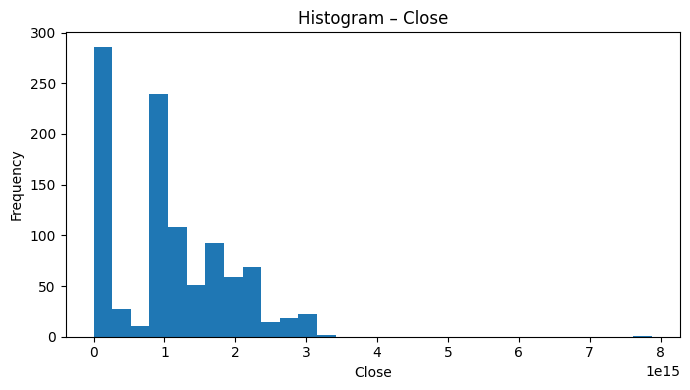

------------------------------------------------------------------------------------------
[Histogram] Close: skew=0.90, kurtosis=3.48 → Lệch phải (đuôi phải dài). Độ phân tán (std)≈838118261929854.75.
Kết luận: cân nhắc log-transform; xem winsorize/capping outlier
------------------------------------------------------------------------------------------


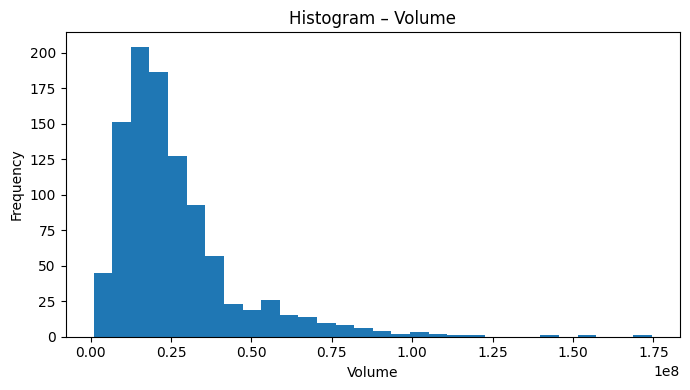

------------------------------------------------------------------------------------------
[Histogram] Volume: skew=2.40, kurtosis=9.04 → Lệch phải (đuôi phải dài). Độ phân tán (std)≈19399495.51.
Kết luận: cân nhắc log-transform; xem winsorize/capping outlier; nên dùng log scale để ổn định phương sai
------------------------------------------------------------------------------------------


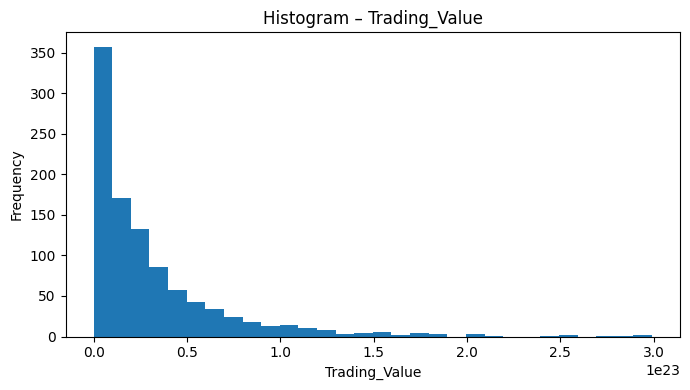

------------------------------------------------------------------------------------------
[Histogram] Trading_Value: skew=2.74, kurtosis=10.20 → Lệch phải (đuôi phải dài). Độ phân tán (std)≈40798446100534907633664.00.
Kết luận: cân nhắc log-transform; xem winsorize/capping outlier
------------------------------------------------------------------------------------------


In [32]:
# =====================================================================
# 1) HISTOGRAMS — Phân bố biến đơn + Diễn giải & Kết luận (DỮ LIỆU HVN)
# =====================================================================

hist_cols = ["Close", "Volume", "Trading_Value"]

for col in hist_cols:
    series = df[col].dropna()
    plt.figure(figsize=(7,4))
    plt.hist(series, bins=30)
    plt.title(f"Histogram – {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    # === Diễn giải & Kết luận cho từng biến ===
    if len(series) >= 3:
        skew = series.skew()
        kurt = series.kurtosis()

        if skew > 0.8:
            skew_tag = "Lệch phải (đuôi phải dài)"
        elif skew < -0.8:
            skew_tag = "Lệch trái (đuôi trái dài)"
        else:
            skew_tag = "Gần đối xứng"

        spread = series.std()

        action = []
        if skew > 0.8 and (series.min() > 0):
            action.append("cân nhắc log-transform")
        if abs(kurt) > 1.5:
            action.append("xem winsorize/capping outlier")
        if col == "Volume":
            action.append("nên dùng log scale để ổn định phương sai")

        print("-"*90)
        print(f"[Histogram] {col}: skew={skew:.2f}, kurtosis={kurt:.2f} → {skew_tag}. "
              f"Độ phân tán (std)≈{spread:.2f}.")
        print("Kết luận:", ("; ".join(action) if action else "Phân bố ổn, chưa cần biến đổi."))
        print("-"*90)


Nhận xét Histogram – Giá đóng cửa (Close)

Phân bố của giá đóng cửa cổ phiếu HVN có đặc điểm lệch phải với hệ số skewness = 0,90, cho thấy phần đuôi bên phải dài hơn so với bên trái. Điều này phản ánh sự xuất hiện của một số mức giá cao bất thường trong tập dữ liệu. Bên cạnh đó, hệ số kurtosis = 3,48 (> 3) cho thấy phân bố có độ nhọn cao và tồn tại các giá trị ngoại lai (outliers). Độ phân tán của giá đóng cửa khá lớn (độ lệch chuẩn xấp xỉ
8,38 × 10^14), cho thấy biến động giá ở mức đáng kể. Do đó, để hạn chế ảnh hưởng của các giá trị cực đoan, có thể cân nhắc thực hiện log-transform hoặc winsorize/capping outliers trước khi phân tích sâu hơn.

Nhận xét Histogram – Khối lượng giao dịch (Volume)

Phân bố khối lượng giao dịch có mức lệch phải rất mạnh với skewness = 2,40, phản ánh sự tồn tại của nhiều phiên giao dịch có khối lượng đột biến cao. Hệ số kurtosis đạt 9,04, cho thấy phân bố có đuôi dày và xuất hiện nhiều giá trị ngoại lai. Độ lệch chuẩn của khối lượng giao dịch lên tới khoảng 19,4 triệu đơn vị, cho thấy mức độ biến động rất lớn giữa các phiên. Vì vậy, để ổn định phương sai và hạn chế ảnh hưởng của outliers, biến Volume nên được biến đổi theo thang log (log scale) trước khi sử dụng trong các mô hình phân tích hoặc dự báo.

Nhận xét Histogram – Giá trị giao dịch (Trading_Value)

Biến giá trị giao dịch cũng thể hiện phân bố lệch phải rất rõ rệt với skewness = 2,74, cho thấy các phiên có giá trị giao dịch lớn chiếm ưu thế ở phần đuôi phải. Đồng thời, hệ số kurtosis = 10,20 phản ánh mức độ tập trung cao quanh giá trị trung tâm kèm theo sự xuất hiện của nhiều giá trị ngoại lai lớn. Độ phân tán của biến này là rất cao (độ lệch chuẩn khoảng
4,08 × 10^22), thể hiện sự chênh lệch mạnh giữa các phiên giao dịch. Do đó, nên cân nhắc áp dụng log-transform và kỹ thuật capping outliers để nâng cao tính ổn định của dữ liệu cho các bước phân tích tiếp theo.

# Tương quan

In [33]:
from google.colab import files
uploaded = files.upload()

Saving CPI.xlsx to CPI (1).xlsx


In [34]:
from google.colab import files
uploaded = files.upload()

Saving giá đầu brent lịch sử.xlsx to giá đầu brent lịch sử (1).xlsx


In [35]:
from google.colab import files
uploaded = files.upload()

Saving tỷ giá usd.xlsx to tỷ giá usd (1).xlsx


In [36]:
import os
os.listdir()

['.config',
 'giá đầu brent lịch sử.xlsx',
 'giá đầu brent lịch sử (1).xlsx',
 'Simplize_HVN_PriceHistory_20251129.xlsx',
 'CPI (1).xlsx',
 'tỷ giá usd.xlsx',
 'tỷ giá usd (1).xlsx',
 'CPI.xlsx',
 'Simplize_HVN_PriceHistory_20251129 (1).xlsx',
 'sample_data']

In [37]:
os.rename("CPI.xlsx", "CPI.xlsx")
os.rename("giá đầu brent lịch sử.xlsx", "Brent.xlsx")
os.rename("tỷ giá usd.xlsx", "USDVND.xlsx")

In [38]:
os.listdir()

['.config',
 'USDVND.xlsx',
 'giá đầu brent lịch sử (1).xlsx',
 'Simplize_HVN_PriceHistory_20251129.xlsx',
 'Brent.xlsx',
 'CPI (1).xlsx',
 'tỷ giá usd (1).xlsx',
 'CPI.xlsx',
 'Simplize_HVN_PriceHistory_20251129 (1).xlsx',
 'sample_data']

In [39]:
df_cpi   = pd.read_excel("CPI.xlsx")
df_brent = pd.read_excel("Brent.xlsx")
df_fx    = pd.read_excel("USDVND.xlsx")

In [40]:
df_cpi.head()
df_brent.head()
df_fx.head()

,Ngày,Lần cuối,Mở,Cao,Thấp,KL,% Thay đổi
0,28/11/2025,26365.0,26372.0,26393.0,26341.5,NaN,-0.0004
1,27/11/2025,26375.5,26379.5,26391.5,26359.0,NaN,0.0000
2,26/11/2025,26376.5,26365.5,26390.0,26354.0,NaN,0.0001
3,25/11/2025,26373.0,26377.0,26392.0,26357.5,NaN,-0.0001
4,24/11/2025,26375.5,26360.0,26391.5,26312.5,NaN,0.0009


In [41]:
import pandas as pd
import numpy as np

# 1) Đọc thô lại file Brent (KHÔNG parse ngày vội)
df_raw = pd.read_excel("/content/Brent.xlsx", dtype={0: object})

# 2) Phát hiện cột ngày tự động
possible_date_cols = [c for c in df_raw.columns if 'ngày' in str(c).lower()]
date_col = possible_date_cols[0] if possible_date_cols else df_raw.columns[0]
print("Cột ngày được chọn:", date_col)

df_raw["Date_str"] = df_raw[date_col].astype(str).str.strip()

# 3) Thử parse theo định dạng Việt Nam và Mỹ
parse_dayfirst   = pd.to_datetime(df_raw["Date_str"], dayfirst=True,  errors="coerce")
parse_monthfirst = pd.to_datetime(df_raw["Date_str"], dayfirst=False, errors="coerce")

print("Dayfirst parse:", parse_dayfirst.notna().sum())
print("Monthfirst parse:", parse_monthfirst.notna().sum())

chosen = parse_dayfirst if parse_dayfirst.notna().sum() >= parse_monthfirst.notna().sum() else parse_monthfirst

# 4) Tìm cột giá Brent
numcols = [c for c in df_raw.columns if pd.api.types.is_numeric_dtype(df_raw[c])]
price_col = "Lần cuối" if "Lần cuối" in df_raw.columns else numcols[0]
print("Cột giá được chọn:", price_col)

# 5) Tạo df_brent chuẩn
df_brent = pd.DataFrame()
df_brent["Date"] = chosen
df_brent["Brent"] = df_raw[price_col]

# 6) Làm sạch
df_brent = df_brent.dropna(subset=["Date"])
df_brent["Brent"] = df_brent["Brent"].astype(str).str.replace(",", "")
df_brent["Brent"] = pd.to_numeric(df_brent["Brent"], errors="coerce")

# 7) Sắp xếp đúng thứ tự thời gian (2021 → 2025)
df_brent = df_brent.sort_values("Date").reset_index(drop=True)

# 8) Kiểm tra kết quả cuối
print("Min Date / Max Date:")
print(df_brent["Date"].min(), df_brent["Date"].max())
print("\nThông tin dữ liệu:")
df_brent.info()

display(df_brent.head())
display(df_brent.tail())


Cột ngày được chọn: Ngày
Dayfirst parse: 631
Monthfirst parse: 631
Cột giá được chọn: Lần cuối
Min Date / Max Date:
2021-11-26 00:00:00 2025-11-28 00:00:00

Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 631 entries, 0 to 630
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    631 non-null    datetime64[ns]
 1   Brent   631 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 10.0 KB


/tmp/ipython-input-760446420.py:16: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  parse_monthfirst = pd.to_datetime(df_raw["Date_str"], dayfirst=False, errors="coerce")


,Date,Brent
0,2021-11-26,72.72
1,2021-11-29,73.44
2,2021-11-30,70.57
3,2021-12-13,74.39
4,2021-12-14,73.70


,Date,Brent
626,2025-11-24,63.37
627,2025-11-25,62.48
628,2025-11-26,63.13
629,2025-11-27,63.34
630,2025-11-28,63.20


In [42]:
print(df_brent["Date"].min(), df_brent["Date"].max())


2021-11-26 00:00:00 2025-11-28 00:00:00


In [43]:
import pandas as pd

df_raw = pd.read_excel("/content/USDVND.xlsx", dtype={0: object})

# phát hiện cột ngày
date_col = [c for c in df_raw.columns if 'ngày' in str(c).lower()][0]
df_raw["Date_str"] = df_raw[date_col].astype(str).str.strip()

# parse ngày
df_raw["Date"] = pd.to_datetime(df_raw["Date_str"], dayfirst=True, errors="coerce")

# phát hiện cột tỷ giá
numcols = [c for c in df_raw.columns if pd.api.types.is_numeric_dtype(df_raw[c])]
rate_col = numcols[0]

df_usd = df_raw[["Date", rate_col]].rename(columns={rate_col: "USDVND"})
df_usd = df_usd.dropna().sort_values("Date").reset_index(drop=True)

print(df_usd["Date"].min(), df_usd["Date"].max())
df_usd.info()
display(df_usd.head())
display(df_usd.tail())


2021-11-26 00:00:00 2025-11-28 00:00:00
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 638 entries, 0 to 637
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    638 non-null    datetime64[ns]
 1   USDVND  638 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 10.1 KB


,Date,USDVND
0,2021-11-26,22678.0
1,2021-11-29,22690.0
2,2021-11-30,22688.0
3,2021-12-13,22975.0
4,2021-12-14,23000.0


,Date,USDVND
633,2025-11-24,26375.5
634,2025-11-25,26373.0
635,2025-11-26,26376.5
636,2025-11-27,26375.5
637,2025-11-28,26365.0


In [44]:

print("Min / Max Date:", df_usd["Date"].min(), df_usd["Date"].max())

Min / Max Date: 2021-11-26 00:00:00 2025-11-28 00:00:00


In [45]:
# CHUẨN HÓA DỮ LIỆU CPI (THEO THÁNG)
import pandas as pd

df_cpi_raw = pd.read_excel("/content/CPI.xlsx")
print("Tên các cột trong file CPI:")
print(df_cpi_raw.columns)
display(df_cpi_raw.head())

Tên các cột trong file CPI:
Index(['COUNTRY', 'INDEX_TYPE', 'COICOP_1999', 'TYPE_OF_TRANSFORMATION',
       'FREQUENCY', 'TIME_PERIOD', 'OBS_VALUE', 'SCALE'],
      dtype='object')


,COUNTRY,INDEX_TYPE,COICOP_1999,TYPE_OF_TRANSFORMATION,FREQUENCY,TIME_PERIOD,OBS_VALUE,SCALE
0,Vietnam,Consumer price index (CPI),Transport,Index,Monthly,2021-M12,106.117464,Units
1,Vietnam,Consumer price index (CPI),Transport,Index,Monthly,2022-M01,107.365830,Units
2,Vietnam,Consumer price index (CPI),Transport,Index,Monthly,2022-M02,109.889893,Units
3,Vietnam,Consumer price index (CPI),Transport,Index,Monthly,2022-M03,115.168014,Units
4,Vietnam,Consumer price index (CPI),Transport,Index,Monthly,2022-M04,114.492899,Units


In [46]:
import pandas as pd

# 1) Đọc file CPI
df_cpi_raw = pd.read_excel("/content/CPI.xlsx")

# 2) Giữ lại đúng 2 cột cần dùng
df_cpi = df_cpi_raw[["TIME_PERIOD", "OBS_VALUE"]].copy()

# 3) Đổi tên cột
df_cpi = df_cpi.rename(columns={
    "TIME_PERIOD": "Date",
    "OBS_VALUE": "CPI"
})

# 4) Chuyển dạng thời gian từ "2021-M12" → datetime (lấy ngày đầu tháng)
df_cpi["Date"] = df_cpi["Date"].astype(str).str.replace("-M", "-", regex=False)
df_cpi["Date"] = pd.to_datetime(df_cpi["Date"], format="%Y-%m")

# 5) Chuyển CPI sang dạng số
df_cpi["CPI"] = pd.to_numeric(df_cpi["CPI"], errors="coerce")

# 6) Sắp xếp theo thời gian tăng dần
df_cpi = df_cpi.sort_values("Date").reset_index(drop=True)

# 7) Kiểm tra kết quả
print(" CPI - Min / Max Date:", df_cpi["Date"].min(), df_cpi["Date"].max())
df_cpi.info()
display(df_cpi.head())
display(df_cpi.tail())


 CPI - Min / Max Date: 2021-12-01 00:00:00 2025-03-01 00:00:00
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    40 non-null     datetime64[ns]
 1   CPI     40 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 772.0 bytes


,Date,CPI
0,2021-12-01,106.117464
1,2022-01-01,107.365830
2,2022-02-01,109.889893
3,2022-03-01,115.168014
4,2022-04-01,114.492899


,Date,CPI
35,2024-11-01,107.096011
36,2024-12-01,107.704424
37,2025-01-01,108.722985
38,2025-02-01,109.403264
39,2025-03-01,107.865773


In [47]:
import pandas as pd

# Đọc file CPI đã rename
df_cpi_raw = pd.read_excel("CPI.xlsx")

# Giữ đúng 2 cột cần thiết
df_cpi = df_cpi_raw[["TIME_PERIOD", "OBS_VALUE"]].copy()

# Đổi tên cột
df_cpi = df_cpi.rename(columns={
    "TIME_PERIOD": "Date",
    "OBS_VALUE": "CPI"
})



In [48]:
# Chuyển "2021-M12" → "2021-12-01"
df_cpi["Date"] = pd.to_datetime(
    df_cpi["Date"].str.replace("-M", "-"),
    format="%Y-%m"
)

df_cpi.dtypes

,0
Date,datetime64[ns]
CPI,float64


In [49]:
df_cpi = df_cpi.sort_values("Date").reset_index(drop=True)

print("Min / Max Date CPI:",
      df_cpi["Date"].min(),
      df_cpi["Date"].max())

display(df_cpi.head())
display(df_cpi.tail())

Min / Max Date CPI: 2021-12-01 00:00:00 2025-03-01 00:00:00


,Date,CPI
0,2021-12-01,106.117464
1,2022-01-01,107.365830
2,2022-02-01,109.889893
3,2022-03-01,115.168014
4,2022-04-01,114.492899


,Date,CPI
35,2024-11-01,107.096011
36,2024-12-01,107.704424
37,2025-01-01,108.722985
38,2025-02-01,109.403264
39,2025-03-01,107.865773


In [50]:
# 1) Tạo dải ngày đầy đủ theo CPI
date_range = pd.date_range(
    start=df_cpi["Date"].min(),
    end=df_cpi["Date"].max(),
    freq="D"
)

df_cpi_daily = pd.DataFrame({"Date": date_range})

# Merge CPI tháng vào ngày
df_cpi_daily = df_cpi_daily.merge(df_cpi, on="Date", how="left")

# Forward fill CPI
df_cpi_daily["CPI"] = df_cpi_daily["CPI"].ffill()

print("Min / Max CPI daily:",
      df_cpi_daily["Date"].min(),
      df_cpi_daily["Date"].max())

display(df_cpi_daily.head())
display(df_cpi_daily.tail())


Min / Max CPI daily: 2021-12-01 00:00:00 2025-03-01 00:00:00


,Date,CPI
0,2021-12-01,106.117464
1,2021-12-02,106.117464
2,2021-12-03,106.117464
3,2021-12-04,106.117464
4,2021-12-05,106.117464


,Date,CPI
1182,2025-02-25,109.403264
1183,2025-02-26,109.403264
1184,2025-02-27,109.403264
1185,2025-02-28,109.403264
1186,2025-03-01,107.865773


## 👉 CPI bị thiếu phần cuối (03/2025 → 11/2025)
### CẮT TOÀN BỘ DỮ LIỆU VỀ KHOẢNG CHUNG
### Do hạn chế về dữ liệu CPI, nghiên cứu sử dụng khoảng thời gian từ 26/11/2021 đến 31/03/2025 nhằm đảm bảo tính đồng nhất của bộ dữ liệu.

In [54]:
df_stock = df.copy()
df_cpi   = df_cpi.copy()
df_brent = df_brent.copy()
df_fx    = df_fx.copy()


In [57]:
print("FX columns :", df_fx.columns.tolist())


FX columns : ['Ngày', 'Lần cuối', 'Mở', 'Cao', 'Thấp', 'KL', '% Thay đổi']


In [58]:
df_fx = df_fx.rename(columns={
    "Ngày": "Date"
})

df_fx["Date"] = pd.to_datetime(df_fx["Date"], dayfirst=True)
df_fx = df_fx.sort_values("Date").reset_index(drop=True)

In [59]:
# Kiểm tra lại các mốc thời gian
print("Stock :", df_stock["Date"].min(), df_stock["Date"].max())
print("Brent :", df_brent["Date"].min(), df_brent["Date"].max())
print("USDVND:", df_fx["Date"].min(), df_fx["Date"].max())
print("CPI   :", df_cpi["Date"].min(), df_cpi["Date"].max())


Stock : 2021-11-26 00:00:00 2025-11-28 00:00:00
Brent : 2021-11-26 00:00:00 2025-11-28 00:00:00
USDVND: 2021-01-12 00:00:00 2025-12-11 00:00:00
CPI   : 2021-12-01 00:00:00 2025-03-01 00:00:00


In [60]:
# CHUYỂN CPI THÁNG → CPI NGÀY
# Tạo dải ngày đầy đủ theo CPI
cpi_daily_range = pd.date_range(
    start=df_cpi["Date"].min(),
    end=df_cpi["Date"].max(),
    freq="D"
)

df_cpi_daily = pd.DataFrame({"Date": cpi_daily_range})
# Merge CPI tháng vào dải ngày
df_cpi_daily = df_cpi_daily.merge(
    df_cpi,
    on="Date",
    how="left"
)

# Nội suy tuyến tính
df_cpi_daily["CPI"] = df_cpi_daily["CPI"].interpolate(method="linear")
print("CPI daily:", df_cpi_daily["Date"].min(), df_cpi_daily["Date"].max())
df_cpi_daily.head()




CPI daily: 2021-12-01 00:00:00 2025-03-01 00:00:00


,Date,CPI
0,2021-12-01,106.117464
1,2021-12-02,106.157734
2,2021-12-03,106.198003
3,2021-12-04,106.238273
4,2021-12-05,106.278543


In [62]:
# CẮT TẤT CẢ BIẾN THEO CPI (QUAN TRỌNG)
start_date = df_cpi_daily["Date"].min()
end_date   = df_cpi_daily["Date"].max()


In [65]:
# Cắt từng dataframe
df_stock_cut = df_stock[(df_stock["Date"] >= start_date) & (df_stock["Date"] <= end_date)]
df_brent_cut = df_brent[(df_brent["Date"] >= start_date) & (df_brent["Date"] <= end_date)]
df_fx_cut    = df_fx[(df_fx["Date"]    >= start_date) & (df_fx["Date"]    <= end_date)]


In [66]:

# Kiểm tra lại
print("Stock :", df_stock_cut["Date"].min(), df_stock_cut["Date"].max())
print("Brent :", df_brent_cut["Date"].min(), df_brent_cut["Date"].max())
print("USDVND:", df_fx_cut["Date"].min(), df_fx_cut["Date"].max())
print("CPI   :", df_cpi_daily["Date"].min(), df_cpi_daily["Date"].max())


Stock : 2021-12-01 00:00:00 2025-02-28 00:00:00
Brent : 2021-12-13 00:00:00 2025-02-28 00:00:00
USDVND: 2021-12-13 00:00:00 2025-03-01 00:00:00
CPI   : 2021-12-01 00:00:00 2025-03-01 00:00:00


In [70]:
df_fx_clean = df_fx_cut[["Date", "Lần cuối"]].copy()
df_fx_clean = df_fx_clean.rename(columns={"Lần cuối": "USDVND"})

In [73]:
# Merge từng bước
df_all = df_stock_cut.merge(
    df_brent_cut[["Date", "Brent"]],
    on="Date",
    how="inner"
)

df_all = df_all.merge(
    df_fx_clean,
    on="Date",
    how="inner"
)

df_all = df_all.merge(
    df_cpi_daily[["Date", "CPI"]],
    on="Date",
    how="inner"
)


In [74]:
# Kiểm tra cuối cùng
df_all.info()
df_all.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 495 entries, 0 to 494
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                495 non-null    datetime64[ns]
 1   Open                495 non-null    float64       
 2   High                495 non-null    float64       
 3   Low                 495 non-null    float64       
 4   Close               495 non-null    float64       
 5   Volume              495 non-null    float64       
 6   Return_pct          495 non-null    float64       
 7   Intraday_Range_pct  495 non-null    float64       
 8   Trading_Value       495 non-null    float64       
 9   Brent               495 non-null    float64       
 10  USDVND              495 non-null    float64       
 11  CPI                 495 non-null    float64       
dtypes: datetime64[ns](1), float64(11)
memory usage: 46.5 KB


,Date,Open,High,Low,Close,Volume,Return_pct,Intraday_Range_pct,Trading_Value,Brent,USDVND,CPI
0,2021-12-13,1.899275e+15,1.970202e+15,1.899275e+15,1.962321e+15,80104000.0,5.508475,3.614458,1.571898e+23,74.39,22975.0,106.600702
1,2021-12-14,1.978083e+14,1.993844e+15,1.907155e+15,1.966262e+15,58501000.0,0.200803,4.408818,1.150283e+23,73.70,23000.0,106.640972
2,2021-12-15,1.966262e+15,1.966262e+15,1.899275e+15,1.915036e+14,38879000.0,-90.260521,34.979424,7.445470e+21,73.88,23030.0,106.681242
3,2021-12-16,1.915036e+14,1.934738e+15,1.840169e+15,1.840169e+15,57447000.0,860.905350,5.139186,1.057122e+23,75.02,22990.0,106.721512
4,2021-12-17,1.816526e+14,1.879573e+14,1.816526e+14,1.848049e+13,32928000.0,-98.995717,34.115139,6.085257e+20,73.52,22980.0,106.761782


## Do chỉ số CPI chỉ khả dụng đến tháng 03/2025, nghiên cứu lựa chọn cắt toàn bộ chuỗi dữ liệu theo khoảng thời gian của CPI nhằm đảm bảo tính đồng nhất và tránh sai lệch do dữ liệu thiếu. CPI được nội suy từ tần suất tháng sang ngày để phù hợp với dữ liệu tài chính có tần suất giao dịch hàng ngày.

In [76]:
df_all.to_csv("merged_stock_macro.csv", index=False, encoding="utf-8-sig")